<a href="https://colab.research.google.com/github/amit-sahu-a11y/3d_video_classification/blob/main/muti_model_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Multi-Modal Classification with Dummy Data

This example demonstrates a basic multi-modal classification setup using Keras/TensorFlow. We'll create dummy text and image features, combine them, and train a simple neural network for classification.

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define parameters for the dummy dataset
num_samples = 1000
text_feature_dim = 50  # e.g., output from a text embedding model
image_feature_dim = 100 # e.g., output from a pre-trained CNN
num_classes = 2      # Binary classification

# Generate dummy text features
# These could be embeddings from a pre-trained language model
np.random.seed(42)
text_features = np.random.rand(num_samples, text_feature_dim).astype(np.float32)

# Generate dummy image features
# These could be features extracted from a pre-trained vision model
image_features = np.random.rand(num_samples, image_feature_dim).astype(np.float32)

# Generate dummy labels for classification
# Create a simple rule for labels based on some features for illustrative purposes
# For instance, if sum of first few text features and image features is high, it's class 1
labels = (np.sum(text_features[:, :5], axis=1) + np.sum(image_features[:, :10], axis=1) > 5).astype(int)

# Normalize features (optional but good practice)
scaler_text = StandardScaler()
text_features_scaled = scaler_text.fit_transform(text_features)

scaler_image = StandardScaler()
image_features_scaled = scaler_image.fit_transform(image_features)

print(f"Text features shape: {text_features_scaled.shape}")
print(f"Image features shape: {image_features_scaled.shape}")
print(f"Labels shape: {labels.shape}")

# Split data into training and testing sets
X_text_train, X_text_test, X_image_train, X_image_test, y_train, y_test = train_test_split(
    text_features_scaled, image_features_scaled, labels, test_size=0.2, random_state=42
)

print("\nData split into training and testing sets:")
print(f"X_text_train shape: {X_text_train.shape}")
print(f"X_image_train shape: {X_image_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_text_test shape: {X_text_test.shape}")
print(f"X_image_test shape: {X_image_test.shape}")
print(f"y_test shape: {y_test.shape}")

Text features shape: (1000, 50)
Image features shape: (1000, 100)
Labels shape: (1000,)

Data split into training and testing sets:
X_text_train shape: (800, 50)
X_image_train shape: (800, 100)
y_train shape: (800,)
X_text_test shape: (200, 50)
X_image_test shape: (200, 100)
y_test shape: (200,)


### Build the Multi-Modal Model

Now, let's define the neural network architecture. We'll have two separate input branches for text and image features, process them independently, and then concatenate their outputs before a final classification layer.

In [2]:
# Define input layers for each modality
text_input = keras.Input(shape=(text_feature_dim,), name="text_input")
image_input = keras.Input(shape=(image_feature_dim,), name="image_input")

# Branch for text features
x_text = layers.Dense(64, activation="relu")(text_input)
x_text = layers.Dropout(0.3)(x_text)
x_text = layers.Dense(32, activation="relu")(x_text)

# Branch for image features
x_image = layers.Dense(128, activation="relu")(image_input)
x_image = layers.Dropout(0.3)(x_image)
x_image = layers.Dense(64, activation="relu")(x_image)

# Concatenate the outputs of the two branches
concatenated = layers.concatenate([x_text, x_image])

# Classification head
z = layers.Dense(64, activation="relu")(concatenated)
z = layers.Dropout(0.4)(z)
output = layers.Dense(num_classes, activation="softmax", name="output")(z) # Softmax for multi-class, sigmoid for binary

# Create the multi-modal model
model = keras.Model(inputs=[text_input, image_input], outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,264 │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     12,928 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        130 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,866 (128.38 KB)

 Trainable params: 32,866 (128.38 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model

With the model defined, we can now compile it with an optimizer, loss function, and metrics, and then train it using our dummy data.

In [3]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy for integer labels
    metrics=["accuracy"],
)

# Train the model
history = model.fit(
    {"text_input": X_text_train, "image_input": X_image_train},
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9328 - loss: 0.2096 - val_accuracy: 0.9937 - val_loss: 0.0411
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0815 - val_accuracy: 0.9937 - val_loss: 0.0417
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0613 - val_accuracy: 0.9937 - val_loss: 0.0402
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0502 - val_accuracy: 0.9937 - val_loss: 0.0404
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0402 - val_accuracy: 0.9937 - val_loss: 0.0403
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0322 - val_accuracy: 0.9937 - val_loss: 0.0401
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0291 - val_accuracy: 0.9937 - val_loss: 0.0406
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0255 - val_accuracy: 0.9937 - val_loss

### Evaluate the Model

Finally, let's evaluate the trained model on the test set to see its performance.

In [4]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(
    {"text_input": X_text_test, "image_input": X_image_test},
    y_test,
    verbose=0
)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
predictions = model.predict({"text_input": X_text_test, "image_input": X_image_test})
predicted_classes = np.argmax(predictions, axis=1)

print("\nExample predictions (first 10):")
for i in range(10):
    print(f"True: {y_test[i]}, Predicted: {predicted_classes[i]}, Probabilities: {predictions[i]}")


Test Loss: 0.1354
Test Accuracy: 0.9750
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Example predictions (first 10):
True: 1, Predicted: 1, Probabilities: [0.00184475 0.99815524]
True: 1, Predicted: 1, Probabilities: [0.00486119 0.9951387 ]
True: 1, Predicted: 1, Probabilities: [2.1891523e-04 9.9978113e-01]
True: 1, Predicted: 1, Probabilities: [2.3796722e-04 9.9976206e-01]
True: 1, Predicted: 1, Probabilities: [2.2126592e-04 9.9977875e-01]
True: 1, Predicted: 1, Probabilities: [1.9004894e-04 9.9980998e-01]
True: 1, Predicted: 1, Probabilities: [5.290681e-04 9.994710e-01]
True: 1, Predicted: 1, Probabilities: [7.8130033e-05 9.9992186e-01]
True: 1, Predicted: 1, Probabilities: [3.5783896e-04 9.9964213e-01]
True: 1, Predicted: 1, Probabilities: [0.00257782 0.99742216]


### Plot Training and Validation Accuracy

Let's visualize the training and validation accuracy over epochs to understand the model's learning process and identify potential overfitting.

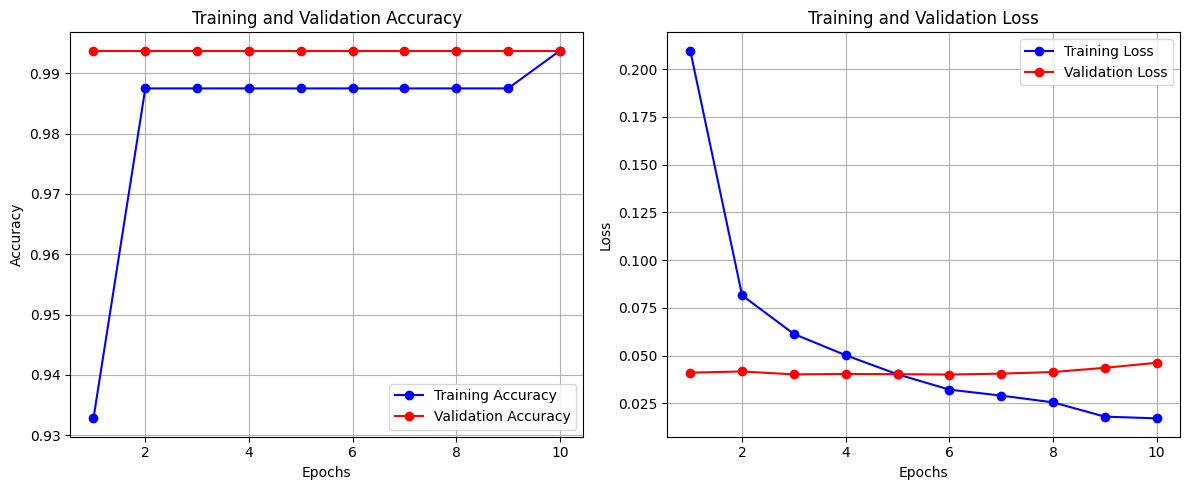

In [5]:
import matplotlib.pyplot as plt

# Get accuracy and loss values from history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()